In [1]:
import SimpleITK as sitk
#from downloaddata import fetch_data as fdata
import pydicom
import numpy as np
import os
import matplotlib.pyplot as plt
import itk
import itkwidgets 
import k3d
from k3d.colormaps import matplotlib_color_maps
#import open3d as o3d
import pandas as pd

ModuleNotFoundError: No module named 'downloaddata'

In [ ]:
path="../../DATA/registration_test/FB_100030____FB,2817673489/study_0c1e55cc/"
path_subfolder1=path+"MR7_bb3b1a0b"#"MR3_33a7c6a2"#"MR4_c61744e9"#"MR3_33a7c6a2"
path_subfolder2=path+"MR5_2e0c276a"
path_subfolder3=path+"MR3_33a7c6a2"

In [ ]:
# read 2 series (sagittal / coronal / axial)
reader1 = sitk.ImageSeriesReader()
dicom_names1 = reader1.GetGDCMSeriesFileNames(path_subfolder1)
reader1.SetFileNames(dicom_names1)
sag_image = reader1.Execute()
sag_image = sitk.Cast(sag_image, sitk.sitkFloat32)

reader2 = sitk.ImageSeriesReader()
dicom_names2 = reader2.GetGDCMSeriesFileNames(path_subfolder2)
reader2.SetFileNames(dicom_names2)
cor_image = reader2.Execute()
cor_image = sitk.Cast(cor_image, sitk.sitkFloat32)

reader3 = sitk.ImageSeriesReader()
dicom_names3 = reader3.GetGDCMSeriesFileNames(path_subfolder3)
reader3.SetFileNames(dicom_names3)
ax_image = reader3.Execute()
ax_image = sitk.Cast(ax_image, sitk.sitkFloat32)

In [ ]:
print('origin: ' + str(sag_image.GetOrigin()))
print('size: ' + str(sag_image.GetSize()))
print('spacing: ' + str(sag_image.GetSpacing()))
print('direction: ' + str(sag_image.GetDirection()))

In [ ]:
print('origin: ' + str(cor_image.GetOrigin()))
print('size: ' + str(cor_image.GetSize()))
print('spacing: ' + str(cor_image.GetSpacing()))
print('direction: ' + str(cor_image.GetDirection()))

In [ ]:
def get_corner(image):
    #print(image.shape)
    points=np.array([[0,0,0], 
                     [image.GetSize()[0],0,0], 
                     [0, image.GetSize()[1], 0], 
                     [image.GetSize()[0], image.GetSize()[1], 0], 
                     [0,0,image.GetSize()[2]],
                     [image.GetSize()[0],0,image.GetSize()[2]], 
                     [0, image.GetSize()[1], image.GetSize()[2]], 
                     [image.GetSize()[0], image.GetSize()[1], image.GetSize()[2]]]).astype(np.float32)
    print(points)
    return points

In [ ]:
def get_corner_bis(image):
    #print(image.shape)
    points=np.array([[0,0,0], 
                     [image.shape[0],0,0], 
                     [0, image.shape[1], 0], 
                     [image.shape[0], image.shape[1], 0], 
                     [0,0,image.shape[2]],
                     [image.shape[0],0,image.shape[2]], 
                     [0, image.shape[1], image.shape[2]], 
                     [image.shape[0], image.shape[1], image.shape[2]]]).astype(np.float32)
    print(points)
    return points

In [ ]:
# get indexes of the 8corners of each volume
x_sag=get_corner(sag_image)#sitk.GetArrayFromImage(sag_image))
x_cor=get_corner(cor_image)#sitk.GetArrayFromImage(cor_image))
x_ax=get_corner(ax_image)#sitk.GetArrayFromImage(ax_image))

In [ ]:
# get spacing of each volume (dependent of orientation)
spacing_sag=np.array([[sag_image.GetSpacing()[0], 0,0],
                        [0, sag_image.GetSpacing()[1],0], 
                        [0,0, sag_image.GetSpacing()[2]]]).astype(np.float32)
spacing_cor=np.array([[cor_image.GetSpacing()[0], 0,0],
                        [0, cor_image.GetSpacing()[1],0], 
                        [0,0, cor_image.GetSpacing()[2]]]).astype(np.float32)
spacing_ax=np.array([[ax_image.GetSpacing()[0], 0,0],
                        [0, ax_image.GetSpacing()[1],0], 
                        [0,0, ax_image.GetSpacing()[2]]]).astype(np.float32)
print(spacing_sag, spacing_cor, spacing_ax)

In [ ]:
# get direction cosin matrix of each volume (dependent of orientation)
dir_sag = np.zeros([3,3])
dir_sag[0][0] = sag_image.GetDirection()[0]
dir_sag[0][1] = sag_image.GetDirection()[1]
dir_sag[0][2] = sag_image.GetDirection()[2]
dir_sag[1][0] = sag_image.GetDirection()[3]
dir_sag[1][1] = sag_image.GetDirection()[4]
dir_sag[1][2] = sag_image.GetDirection()[5]
dir_sag[2][0] = sag_image.GetDirection()[6]
dir_sag[2][1] = sag_image.GetDirection()[7]
dir_sag[2][2] = sag_image.GetDirection()[8]

dir_cor = np.zeros([3,3])
dir_cor[0][0] = cor_image.GetDirection()[0]
dir_cor[0][1] = cor_image.GetDirection()[1]
dir_cor[0][2] = cor_image.GetDirection()[2]
dir_cor[1][0] = cor_image.GetDirection()[3]
dir_cor[1][1] = cor_image.GetDirection()[4]
dir_cor[1][2] = cor_image.GetDirection()[5]
dir_cor[2][0] = cor_image.GetDirection()[6]
dir_cor[2][1] = cor_image.GetDirection()[7]
dir_cor[2][2] = cor_image.GetDirection()[8]

dir_ax = np.zeros([3,3])
dir_ax[0][0] = ax_image.GetDirection()[0]
dir_ax[0][1] = ax_image.GetDirection()[1]
dir_ax[0][2] = ax_image.GetDirection()[2]
dir_ax[1][0] = ax_image.GetDirection()[3]
dir_ax[1][1] = ax_image.GetDirection()[4]
dir_ax[1][2] = ax_image.GetDirection()[5]
dir_ax[2][0] = ax_image.GetDirection()[6]
dir_ax[2][1] = ax_image.GetDirection()[7]
dir_ax[2][2] = ax_image.GetDirection()[8]

In [ ]:
A_sag=np.dot(dir_sag.astype(np.float32), spacing_sag)
A_cor=np.dot(dir_cor, spacing_cor)
A_ax=np.dot(dir_ax, spacing_ax)

In [ ]:
origin_sag= sag_image.GetOrigin()
origin_cor= cor_image.GetOrigin()
origin_ax = ax_image.GetOrigin()
print(origin_cor, origin_ax, origin_sag)

In [ ]:
def calcul_physicsCoo(ori, p, A):
    #phyCoo=[]
    phyCoo=[]
    #mat=np.identity(4)
    #mat[0][0]=A[0][0]
    #mat[0][1]=A[0][1]
    #mat[0][2]=A[0][2]
    #mat[1][0]=A[1][0]
    #mat[1][1]=A[1][1]
    #mat[1][2]=A[1][2]
    #mat[2][0]=A[2][0]
    #mat[2][1]=A[2][1]
    #mat[2][2]=A[2][2]
    #mat[0][3]=ori[0]
    #mat[1][3]=ori[1]
    #mat[2][3]=ori[2]
    
    
    for i in range(p.shape[0]):
        #index=np.transpose(p)[:,i]
        #idx=np.array([index[0], index[1], index[2], 1.])
        #p_c=np.dot(mat, idx)
        #pp_c=np.array([p_c[0], p_c[1], p_c[2]])
        print(np.transpose(p)[:,i].shape)
        p_c=ori+np.dot(A, np.transpose(p)[:,i])
        print(p_c, np.array(ori)+np.dot(A, np.transpose(p)[:,i]))
        #phyCoo.append(pp_c)
        phyCoo.append(p_c)
                       
    #phyCoo=np.array(phyCoo)
    phyCoo=np.array(phyCoo)
    return phyCoo

In [14]:
xspa_sag=calcul_physicsCoo(np.array(origin_sag).astype(np.float32), x_sag, A_sag)
print(xspa_sag)

xspa_cor=calcul_physicsCoo(np.array(origin_cor).astype(np.float32), x_cor, A_cor)
print(xspa_cor)

xspa_ax=calcul_physicsCoo(np.array(origin_ax).astype(np.float32), x_ax, A_ax)
print(xspa_ax)

(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
[[ 117.90852  -103.56081    53.280396]
 [ 137.38895    35.077255   53.280396]
 [ 122.293144 -104.1769    -86.64957 ]
 [ 141.77357    34.461166  -86.64957 ]
 [  13.388123  -88.874344   49.940647]
 [  32.868553   49.763718   49.940647]
 [  17.772743  -89.49044   -89.98932 ]
 [  37.253174   49.14763   -89.98932 ]]
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
[[  20.95518494 -102.72428131   48.84761429]
 [ 157.69235939  -72.93023826   52.75403484]
 [  23.68053311  -96.8954473   -91.0044403 ]
 [ 160.41770757  -67.10140424  -87.09801974]
 [  -3.02772508    6.80593609   52.94531366]
 [ 133.70944938   36.59997914   56.85173422]
 [  -0.3023769    12.6347701   -86.90674092]
 [ 136.43479755   42.42881316  -83.00032037]]
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
(3,)
[[  29.4393425  -105.36338043  -81.23900604]
 [ 165.13566865  -72.46070528  -71.04483927]
 [  -3.89087197   30.51549122  -76.13713941]
 [ 131.80545418   63.41816637  -65.94297263]
 [  22.50814672 -111.23990

In [34]:
plt_points = k3d.points(positions=xspa_sag.astype(np.float32),
                        point_size=2.7,
                        shader='3d',
                        color=0x3f6bc5) #, 0x6a329f, 0xc90076, 0xead1dc, 0xd5a6bd, 0xc27ba0, 0xa64d79, 0x741b47])
plt_points_cor = k3d.points(positions=xspa_cor.astype(np.float32),
                        point_size=2.7,
                        shader='3d',
                        color=0xde49a1)
plt_points_ax = k3d.points(positions=xspa_ax.astype(np.float32),
                        point_size=2.7,
                        shader='3d',
                        color=0xead1dc)

plt_points_ori = k3d.points(positions=np.array([xspa_sag[0], xspa_cor[1], xspa_ax[5]]).astype(np.float32),
                        point_size=4,
                        shader='3d',
                        color=0xc27ba0)
plt_points_z = k3d.points(positions=np.array([0., 0.,0.]).astype(np.float32),
                        point_size=15,
                        shader='3d',
                        color=0xc27ba0)
plot = k3d.plot()
#plot += plt_vectors
plot += plt_points
plot += plt_points_cor
plot += plt_points_ax
plot += plt_points_z
plot += plt_points_ori
plot.display()

Output()

In [ ]:
# get the nearest origin point from the reference origin point
o_sag= xspa_sag[0]
o_cor= xspa_cor[1]
o_ax = xspa_ax[5]
print(o_cor, o_ax, o_sag)

[157.69235939 -72.93023826  52.75403484] [158.20447287 -78.33723272  40.18458261] [ 117.90852356 -103.56080627   53.28039551]


In [ ]:
# set the rotation matrix using a volume orientation as reference
o_dir_sag = np.zeros([3,3])
o_dir_sag[0][0] = sag_image.GetDirection()[0]
o_dir_sag[0][1] = sag_image.GetDirection()[1]
o_dir_sag[0][2] = sag_image.GetDirection()[2]
o_dir_sag[1][0] = sag_image.GetDirection()[3]
o_dir_sag[1][1] = sag_image.GetDirection()[4]
o_dir_sag[1][2] = sag_image.GetDirection()[5]
o_dir_sag[2][0] = sag_image.GetDirection()[6]
o_dir_sag[2][1] = sag_image.GetDirection()[7]
o_dir_sag[2][2] = sag_image.GetDirection()[8]

o_dir_cor = np.zeros([3,3])
o_dir_cor[0][0] = cor_image.GetDirection()[6]
o_dir_cor[0][1] = cor_image.GetDirection()[7]
o_dir_cor[0][2] = cor_image.GetDirection()[8]
o_dir_cor[1][0] = cor_image.GetDirection()[3]
o_dir_cor[1][1] = cor_image.GetDirection()[4]
o_dir_cor[1][2] = cor_image.GetDirection()[5]
o_dir_cor[2][0] = -cor_image.GetDirection()[0]
o_dir_cor[2][1] = -cor_image.GetDirection()[1]
o_dir_cor[2][2] = -cor_image.GetDirection()[2]

o_dir_ax = np.zeros([3,3])
o_dir_ax[0][0] = ax_image.GetDirection()[3]
o_dir_ax[0][1] = ax_image.GetDirection()[4]
o_dir_ax[0][2] = ax_image.GetDirection()[5]
o_dir_ax[1][0] = -ax_image.GetDirection()[6]
o_dir_ax[1][1] = -ax_image.GetDirection()[7]
o_dir_ax[1][2] = -ax_image.GetDirection()[8]
o_dir_ax[2][0] = -ax_image.GetDirection()[0]
o_dir_ax[2][1] = -ax_image.GetDirection()[1]
o_dir_ax[2][2] = -ax_image.GetDirection()[2]

print(o_dir_sag, o_dir_cor, o_dir_ax)

[[ 1.39145941e-01  3.13187210e-02 -9.89776512e-01]
 [ 9.90271885e-01 -4.40068726e-03  1.39076335e-01]
 [-3.95177715e-09 -9.99499761e-01 -3.16263867e-02]] [[ 0.027903   -0.99894325  0.03652139]
 [ 0.21281459  0.04163453  0.97620516]
 [-0.9766941  -0.01946677  0.21375143]] [[ 0.23501911  0.97056337 -0.05265706]
 [-0.07281548 -0.0364419  -0.99667943]
 [-0.96925947  0.23807296  0.06210749]]


In [ ]:
# get spacing of each volume (dependent of orientation)
o_spacing_sag=np.array([[sag_image.GetSpacing()[0], 0,0],
                        [0, sag_image.GetSpacing()[1],0], 
                        [0,0, sag_image.GetSpacing()[2]]]).astype(np.float32)
o_spacing_cor=np.array([[cor_image.GetSpacing()[2], 0,0],
                        [0, cor_image.GetSpacing()[1],0], 
                        [0,0, cor_image.GetSpacing()[0]]]).astype(np.float32)
o_spacing_ax=np.array([[ax_image.GetSpacing()[1], 0,0],
                        [0, ax_image.GetSpacing()[2],0], 
                        [0,0, ax_image.GetSpacing()[0]]]).astype(np.float32)
print(o_spacing_sag, o_spacing_cor, o_spacing_ax)

[[0.4375    0.        0.       ]
 [0.        0.4375    0.       ]
 [0.        0.        3.3000002]] [[3.3    0.     0.    ]
 [0.     0.4375 0.    ]
 [0.     0.     0.4375]] [[0.4375 0.     0.    ]
 [0.     3.6    0.    ]
 [0.     0.     0.4375]]


In [ ]:
o_A_sag=np.dot(o_dir_sag, o_spacing_sag)
o_A_cor=np.dot(o_dir_cor, o_spacing_cor)
o_A_ax=np.dot(o_dir_ax, o_spacing_ax)

In [ ]:
# rotate volume 
m_sag=sitk.GetArrayFromImage(sag_image).transpose(1, 2, 0)
m_cor=sitk.GetArrayFromImage(cor_image)#.transpose(1, 2, 0)#, 1, (0,2))#.transpose(1, 2, 0), 1, (0,2))
m_ax= sitk.GetArrayFromImage(ax_image).transpose(1,0, 2 )#, 2, (2,1))#.transpose(1, 2, 0), 2, (2,1))
#m_ax=np.rot90(m_ax, 1, (0,2))
print(m_sag.shape, m_cor.shape, m_ax.shape)
print(sag_image.GetSize(), cor_image.GetSize(), ax_image.GetSize())

(320, 320, 32) (34, 320, 320) (320, 31, 320)
(320, 320, 32) (320, 320, 34) (320, 320, 31)


In [ ]:
# get indexes of the 8corners of each volume
o_x_sag=get_corner_bis(m_sag)
o_x_cor=get_corner_bis(m_cor)
o_x_ax=get_corner_bis(m_ax)

[[  0.   0.   0.]
 [320.   0.   0.]
 [  0. 320.   0.]
 [320. 320.   0.]
 [  0.   0.  32.]
 [320.   0.  32.]
 [  0. 320.  32.]
 [320. 320.  32.]]
[[  0.   0.   0.]
 [320.   0.   0.]
 [  0. 320.   0.]
 [320. 320.   0.]
 [  0.   0.  34.]
 [320.   0.  34.]
 [  0. 320.  34.]
 [320. 320.  34.]]
[[  0.   0.   0.]
 [320.   0.   0.]
 [  0.  31.   0.]
 [320.  31.   0.]
 [  0.   0. 320.]
 [320.   0. 320.]
 [  0.  31. 320.]
 [320.  31. 320.]]


In [35]:
xP_sag=calcul_physicsCoo(np.array(o_sag).astype(np.float32), o_x_sag, o_A_sag)
print(xP_sag)

xP_cor=calcul_physicsCoo(np.array(o_cor).astype(np.float32), o_x_cor, o_A_cor)
print(xP_cor)

xP_ax=calcul_physicsCoo(np.array(o_ax).astype(np.float32), o_x_ax, o_A_ax)
print(xP_ax)

[[ 117.90852356 -103.56080627   53.28039551]
 [ 137.38895536   35.07725768   53.28039495]
 [ 122.2931445  -104.17690249  -86.64957099]
 [ 141.7735763    34.46116146  -86.64957155]
 [  13.3881178   -88.87434444   49.94064888]
 [  32.8685496    49.76371951   49.94064833]
 [  17.77273874  -89.49044066  -89.98931762]
 [  37.25317054   49.14762329  -89.98931817]]
[[ 157.69235229  -72.93023682   52.75403595]
 [ 187.15792406  151.80197041 -978.63492215]
 [  17.84029771  -67.1014028    50.02868777]
 [  47.30586948  157.63080442 -981.36027033]
 [ 158.2356079   -58.40918506   55.93358846]
 [ 187.70117967  166.32302217 -975.45536964]
 [  18.38355332  -52.58035104   53.20824028]
 [  47.84912508  172.15185618 -978.18071782]]
[[ 158.20446777  -78.3372345    40.18458176]
 [ 191.10714293  -88.53140127  -95.5117444 ]
 [ 266.51933687  -82.40415093   66.75352344]
 [ 299.42201203  -92.59831771  -68.94280271]
 [ 150.83247975 -217.87235524   48.87963046]
 [ 183.7351549  -228.06652202  -86.81669569]
 [ 259.1

In [26]:
plt_points_o = k3d.points(positions=xP_sag.astype(np.float32),
                        point_size=2.7,
                        shader='3d',
                        color=0x3f6bc5) #, 0x6a329f, 0xc90076, 0xead1dc, 0xd5a6bd, 0xc27ba0, 0xa64d79, 0x741b47])
plt_points_cor_o = k3d.points(positions=xP_cor.astype(np.float32),
                        point_size=2.7,
                        shader='3d',
                        color=0xde49a1)
#plt_points_ax_o = k3d.points(positions=xP_ax.astype(np.float32),
                        #point_size=2.7,
                        #shader='3d',
                        #color=0xead1dc)

plt_points_ori_o = k3d.points(positions=np.array([xspa_sag[0], xspa_cor[1], xspa_ax[5]]).astype(np.float32),
                        point_size=4,
                        shader='3d',
                        color=0xc27ba0)
plot = k3d.plot()
#plot += plt_vectors
plot += plt_points_o
plot += plt_points_cor_o
#plot += plt_points_ax_o
#plot += plt_points_origins
plot += plt_points_ori_o
plot.display()

Output()

In [31]:
from itkwidgets import view

def itk_view_from_simpleitk(image, sp, direction, origin):
    """Get a view of an ITK image from a SimpleITK image."""
    
    np_view = sitk.GetArrayViewFromImage(image)
    #print(image.shape)
    itk_view = itk.image_view_from_array(np_view)
    #sp= spacing_reshape(image.GetSpacing(),orientation)
    print(cor_image.GetSize(), origin, direction, sp.diagonal())
    itk_view.SetSpacing(sp.diagonal())
    itk_view.SetOrigin(origin)
    
    #itkspacing = itk.matrix_from_array(sp)
    
    itkdir = itk.matrix_from_array(direction)
    
    itk_view.SetDirection(direction)

    return itk_view

(320, 320, 34) [157.69235939 -72.93023826  52.75403484] [[ 0.027903   -0.99894325  0.03652139]
 [ 0.21281459  0.04163453  0.97620516]
 [-0.9766941  -0.01946677  0.21375143]] [3.29999999 0.4375     0.4375    ]



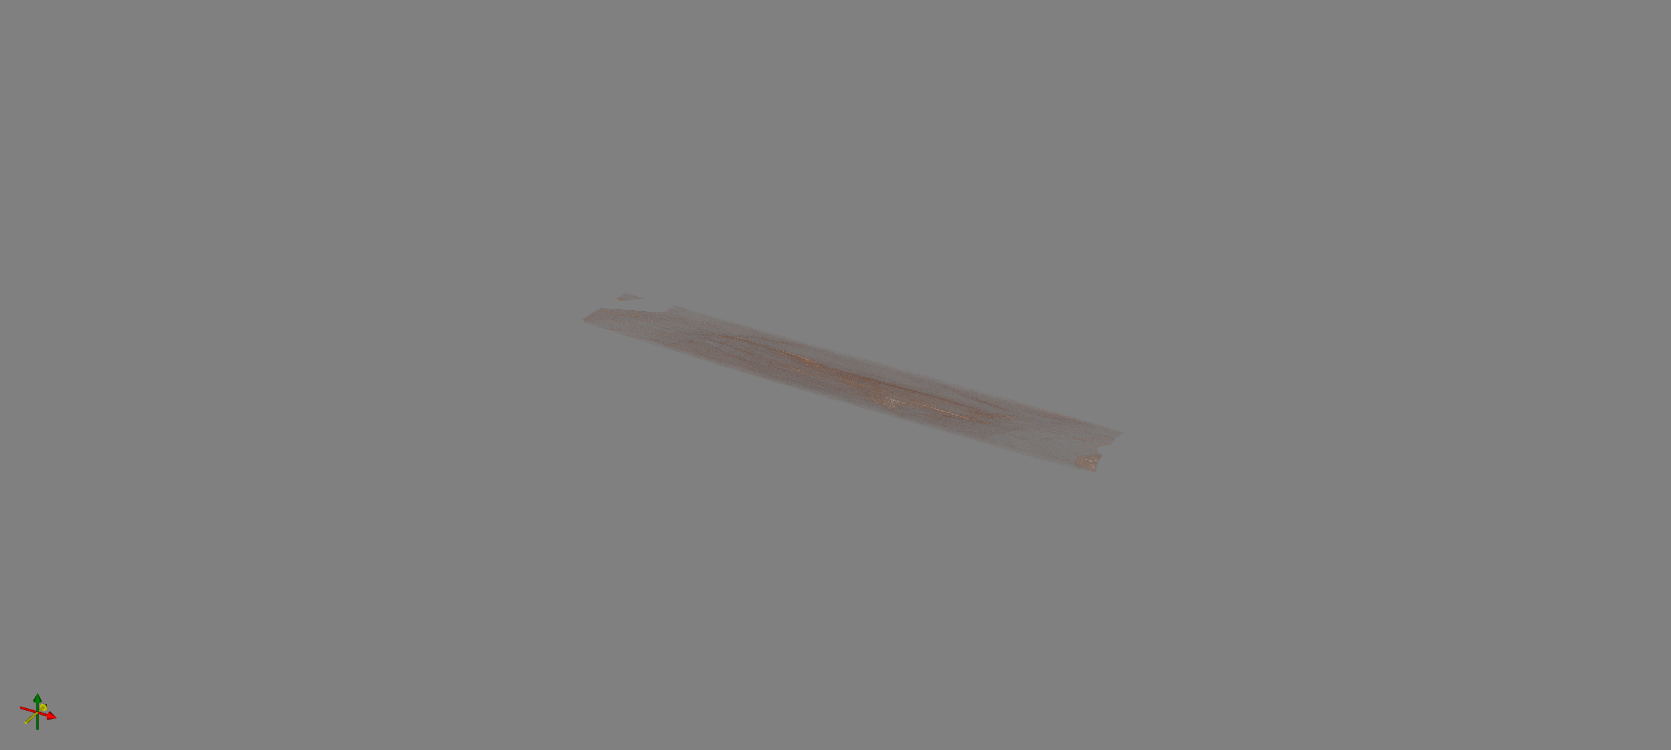
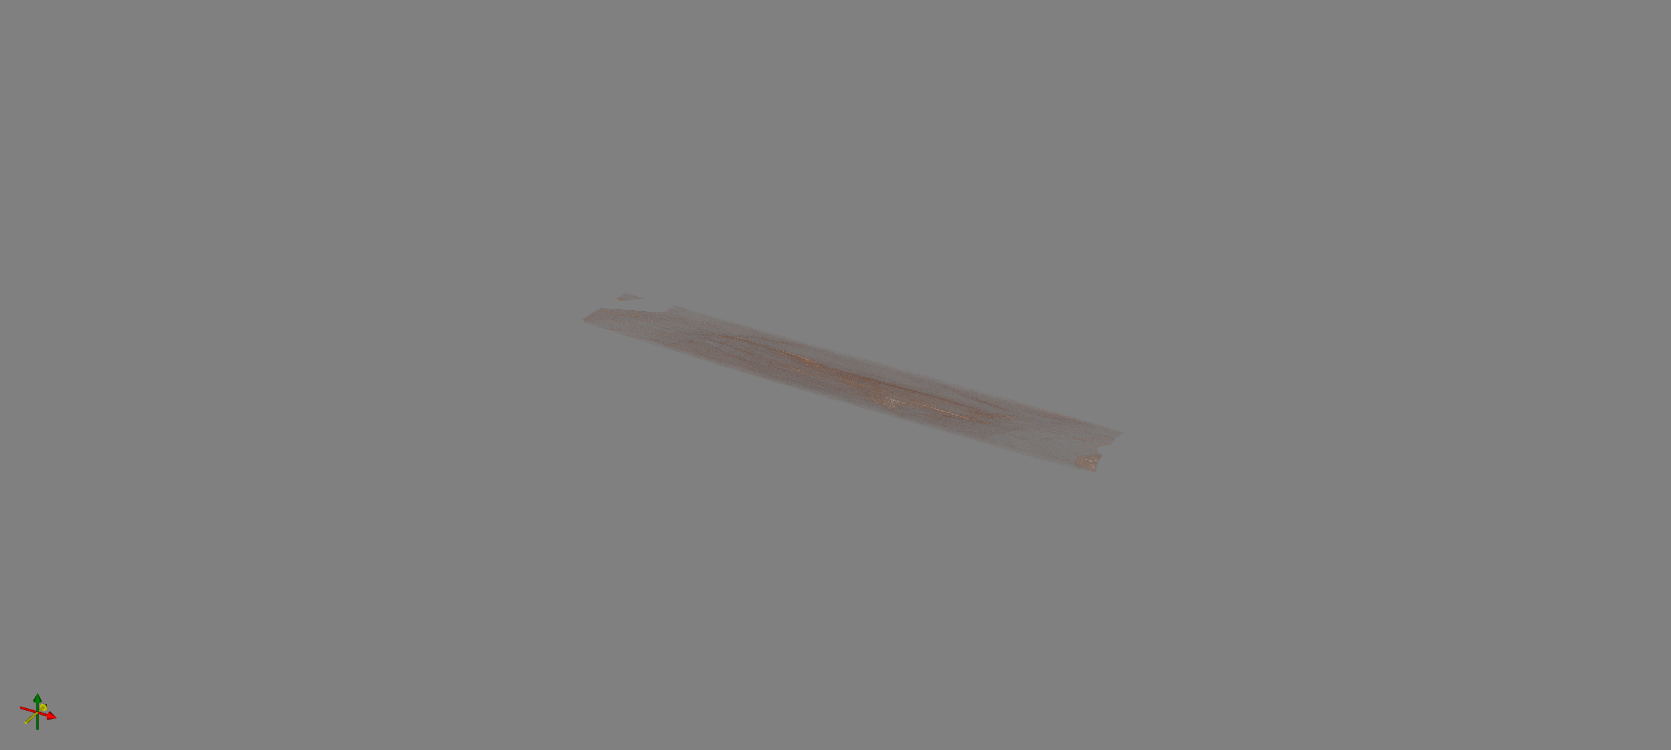

<IPython.core.display.Javascript object>

In [32]:
spa=np.array([[cor_image.GetSpacing()[2], 0,0],
              [0, cor_image.GetSpacing()[1],0], 
              [0,0, cor_image.GetSpacing()[0]]])
itk_view = itk_view_from_simpleitk(cor_image, spa, o_dir_cor, o_cor)
itkwidgets.view(itk_view)